# ARTI 403 – Image Processing
## Lab 4: Intensity Transformations and Filtering – Spatial Domain

**Student name:** ]Danyal Salman Alhashem 
**Student ID:**2240002713

**Outcome #2:** Write a program that implements fundamental image processing algorithms.

**Contents**
- **Part A – Procedural tasks:** Task 1 (Thresholding), Task 2 (Histogram processing: contrast stretching)
- **Part B – Assessment:** Task 1 (Rescale 3rd–80th percentiles), Task 2 (Histogram equalization), Task 3 (Histogram matching)

All input images are stored in the `images/` folder; the figures produced are saved to `outputs/`.

In [1]:
import os
import cv2
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from skimage import data, img_as_float, img_as_ubyte
from skimage import exposure

os.makedirs('outputs', exist_ok=True)
print('OpenCV', cv2.__version__)
print('NumPy', np.__version__)
print('Matplotlib', matplotlib.__version__)

OpenCV 5.0.0
NumPy 2.1.3
Matplotlib 3.10.0


# Part A – Procedural Tasks

## Task #1: Thresholding
### Step #1: Apply thresholding with a fixed threshold on an image

`cv2.threshold(img, T, 255, cv2.THRESH_BINARY)` sets every pixel with intensity **> T** to 255 (white, foreground) and all others to 0 (black, background).
We try T = 0, 50, 100, 150, 200 on the Parrot image.

> Note: `cv2.imshow()` opens separate desktop windows and does not render inside Jupyter, so the results are displayed with Matplotlib instead. The thresholding itself is identical to the manual's code.

Image shape: (340, 453) | dtype: uint8


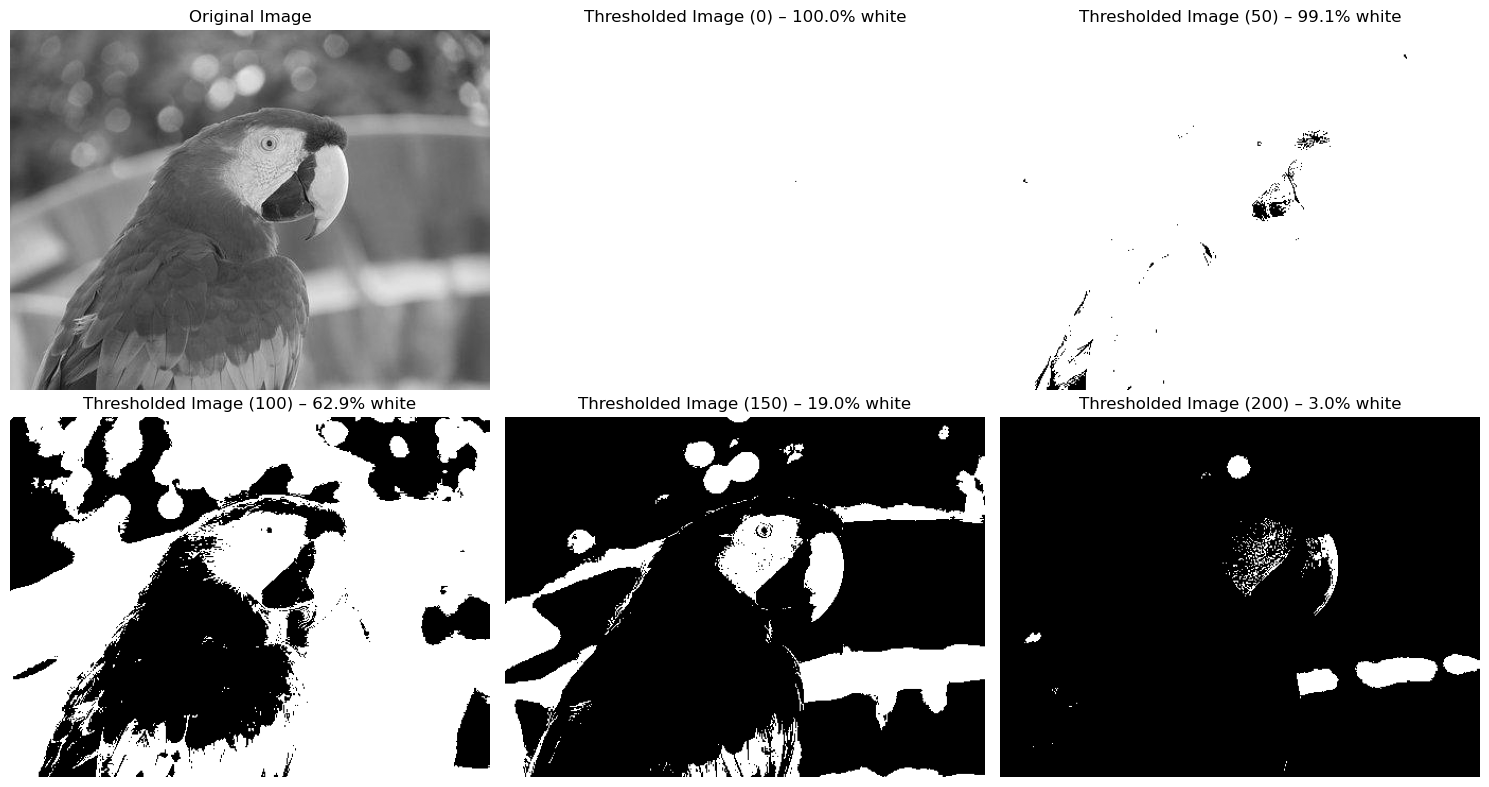

In [2]:
# Load the image in grayscale
img = cv2.imread('images/Parrot.png', cv2.IMREAD_GRAYSCALE)
print('Image shape:', img.shape, '| dtype:', img.dtype)

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

# Display the original image
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

# Apply thresholding with different threshold values
for i, threshold_value in enumerate(threshold_values, start=1):
    ret, thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    white = 100 * np.count_nonzero(thresh) / thresh.size
    axes[i].imshow(thresh, cmap='gray', vmin=0, vmax=255)
    axes[i].set_title(f'Thresholded Image ({threshold_value}) – {white:.1f}% white')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('outputs/A1_thresholding.png', dpi=110, bbox_inches='tight')
plt.show()

**Observation:** With T = 0 almost the whole image becomes white (every pixel above 0 is foreground). As T increases, fewer pixels exceed it, so the white area shrinks; at T = 200 only the brightest regions of the parrot remain. T = 100 separates the dark plumage (black) from the brighter background (62.9% white), while T = 150 isolates the bright face, beak and background highlights (19% white). No single value is perfect, which shows that the choice of T depends on the image content and on what we want to extract.

## Task #2: Histogram Processing
### Step #1: Load necessary libraries (done in the first cell)
### Step #2: Load the moon image

In [3]:
img = data.moon()
print('Moon image shape:', img.shape, '| dtype:', img.dtype,
      '| min =', img.min(), '| max =', img.max())

Moon image shape: (512, 512) | dtype: uint8 | min = 0 | max = 255


### Step #3: Contrast stretching
Rescale intensity values to include all intensities that fall within the 2nd and 98th percentiles.

In [4]:
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))
print(f'2nd percentile = {p2}, 98th percentile = {p98}')
print('Rescaled range:', img_rescale.min(), '-', img_rescale.max())

2nd percentile = 78.0, 98th percentile = 129.0
Rescaled range: 0 - 255


### Step #4: Display the image with its histogram for Step #2 and Step #3

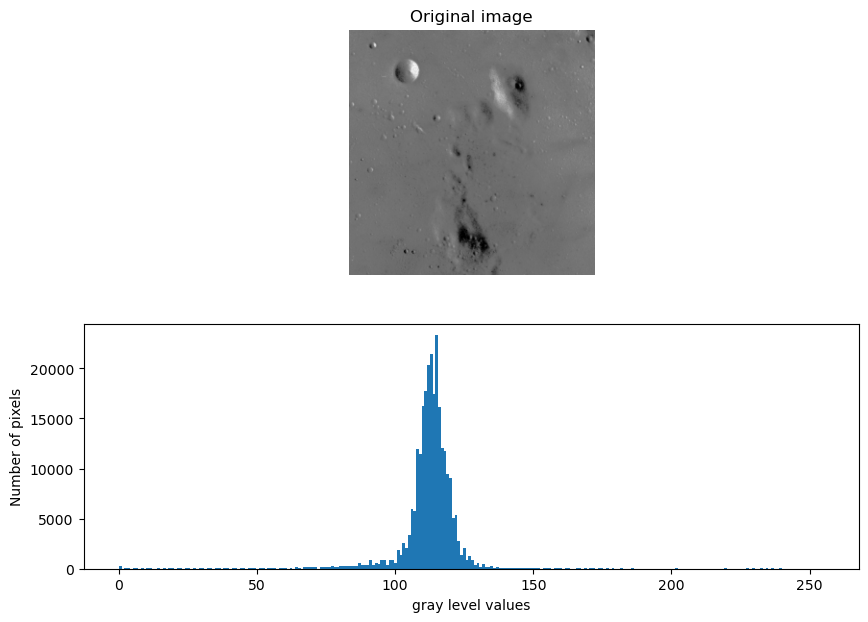

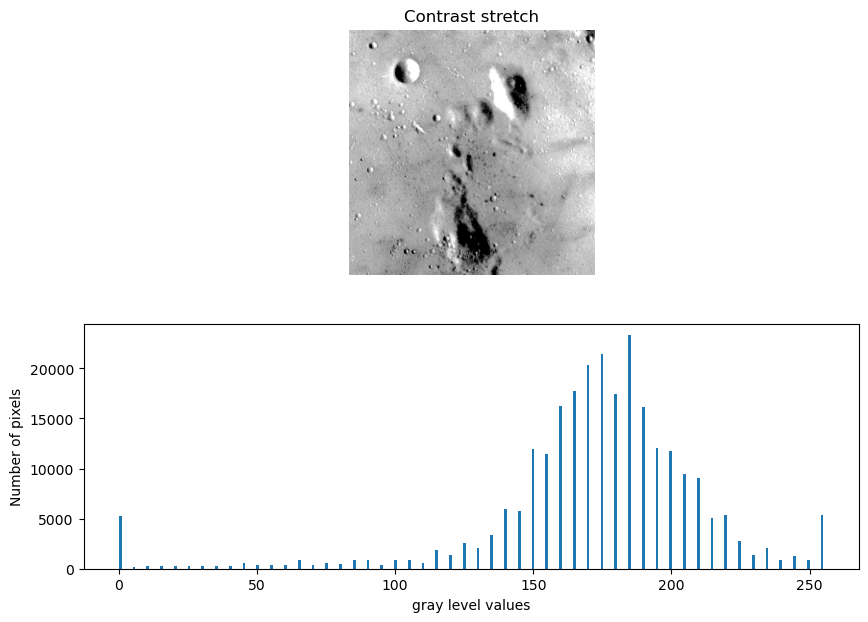

In [5]:
fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Original image')
fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.savefig('outputs/A2_original_moon.png', dpi=110, bbox_inches='tight')
plt.show()

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.savefig('outputs/A2_contrast_stretch_2_98.png', dpi=110, bbox_inches='tight')
plt.show()

**Observation:** The original moon histogram is concentrated in a narrow band of gray levels, so the image looks dull. After stretching the 2nd–98th percentile range to the full 0–255 range, the histogram is spread across all gray levels and the craters show much more contrast. The stretched histogram has a comb-like shape (empty bins between used levels) because a linear stretch only moves the existing ~50 gray levels further apart; it cannot create new ones. About 2% of pixels on each side are clipped to 0 and 255.

# Part B – Assessment

## Assessment Task #1
Using the same moon image, rescale intensity values to include all intensities that fall within the **3rd and 80th percentiles**, and plot the histogram.

3rd percentile = 87.0, 80th percentile = 118.0
Rescaled range: 0 - 255
Pixels saturated to 255: 21.0%


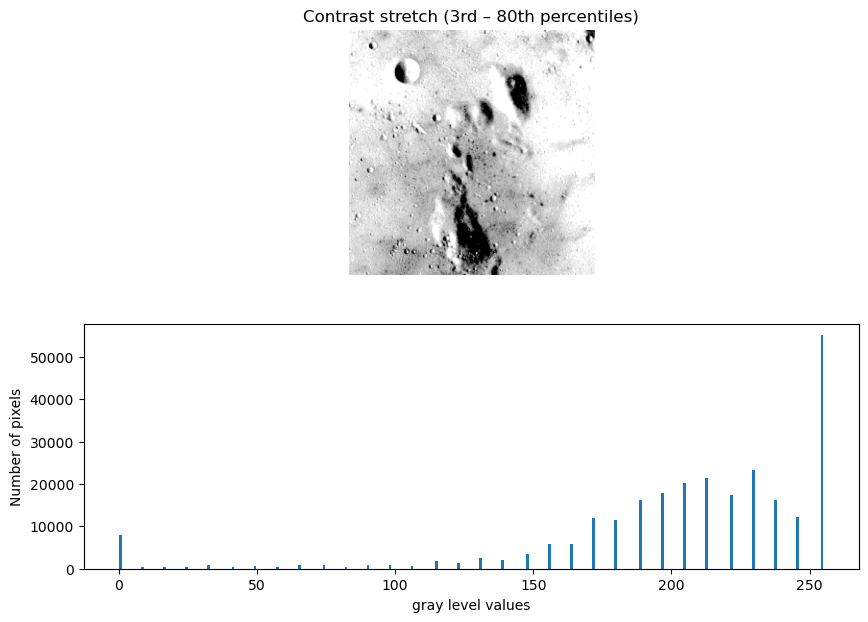

In [6]:
img = data.moon()

# Contrast stretching between the 3rd and 80th percentiles
p3, p80 = np.percentile(img, (3, 80))
img_rescale_3_80 = exposure.rescale_intensity(img, in_range=(p3, p80))
print(f'3rd percentile = {p3}, 80th percentile = {p80}')
print('Rescaled range:', img_rescale_3_80.min(), '-', img_rescale_3_80.max())
sat = 100 * np.mean(img_rescale_3_80 == 255)
print(f'Pixels saturated to 255: {sat:.1f}%')

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale_3_80, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch (3rd – 80th percentiles)')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale_3_80.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.savefig('outputs/B1_contrast_stretch_3_80.png', dpi=110, bbox_inches='tight')
plt.show()

Comparison of the original image, the 2–98 stretch and the 3–80 stretch:

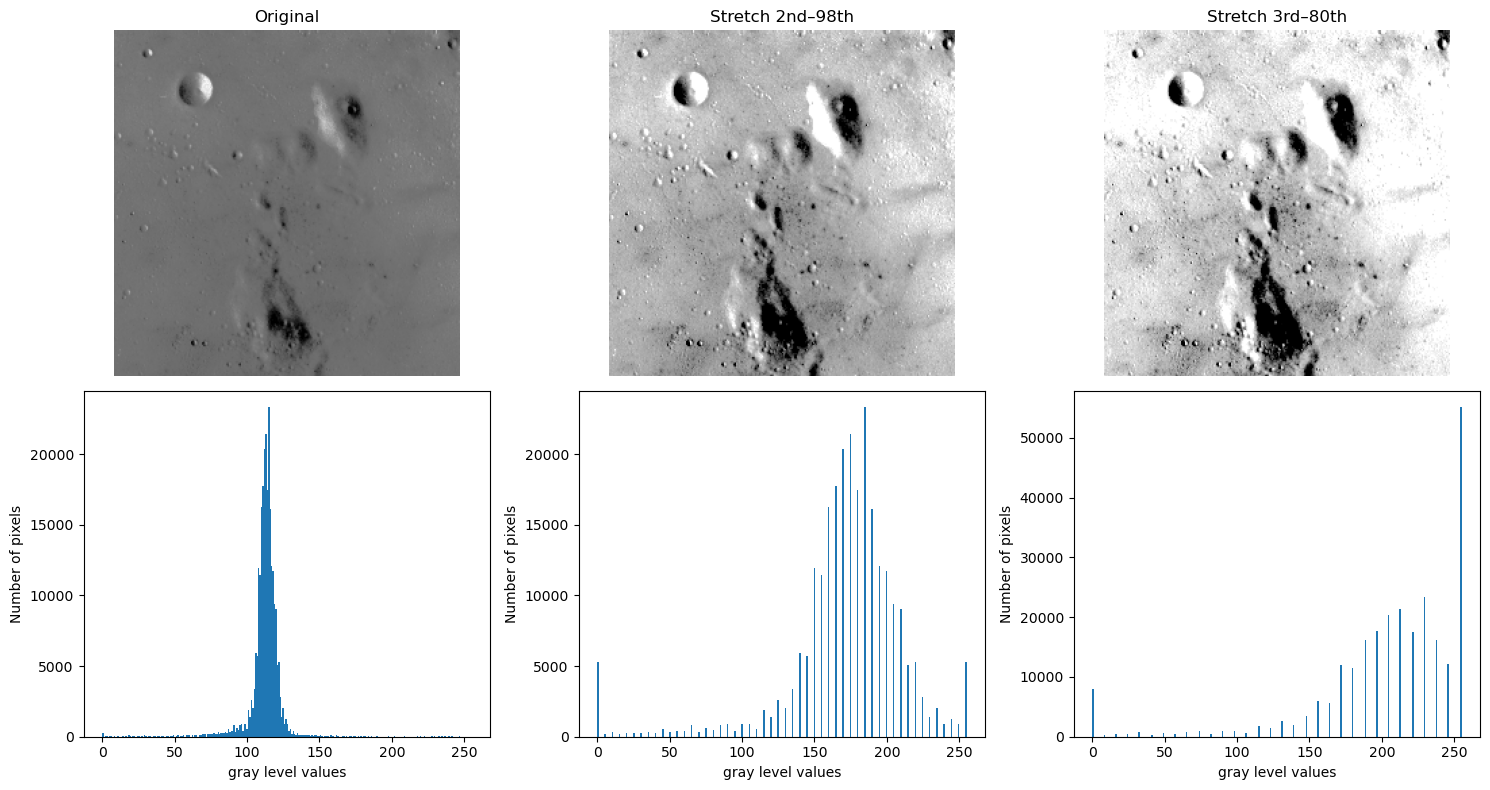

In [7]:
images = [img, img_rescale, img_rescale_3_80]
titles = ['Original', 'Stretch 2nd–98th', 'Stretch 3rd–80th']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i in range(3):
    axes[0, i].imshow(images[i], cmap='gray', vmin=0, vmax=255)
    axes[0, i].set_title(titles[i])
    axes[0, i].axis('off')
    axes[1, i].hist(images[i].flat, bins=256, range=(0, 255))
    axes[1, i].set_xlabel('gray level values')
    axes[1, i].set_ylabel('Number of pixels')
plt.tight_layout()
plt.savefig('outputs/B1_comparison.png', dpi=110, bbox_inches='tight')
plt.show()

**Discussion:** Because the upper limit is now the 80th percentile instead of the 98th, the top 20% of pixels (everything brighter than the 80th percentile) is clipped to 255. This produces a tall spike at 255 in the histogram and makes bright regions appear washed out/saturated, while the darker and mid-tone details are stretched more strongly than with the 2–98 range. The 2–98 range gives a more balanced result; the 3–80 range trades highlight detail for extra contrast in the darker areas.

## Assessment Task #2
Using the same moon image and `exposure.equalize_hist`, display the image and its histogram after flattening the histogram (histogram equalization).

equalize_hist output dtype: float64 | range: 0.00091552734375 - 1.0


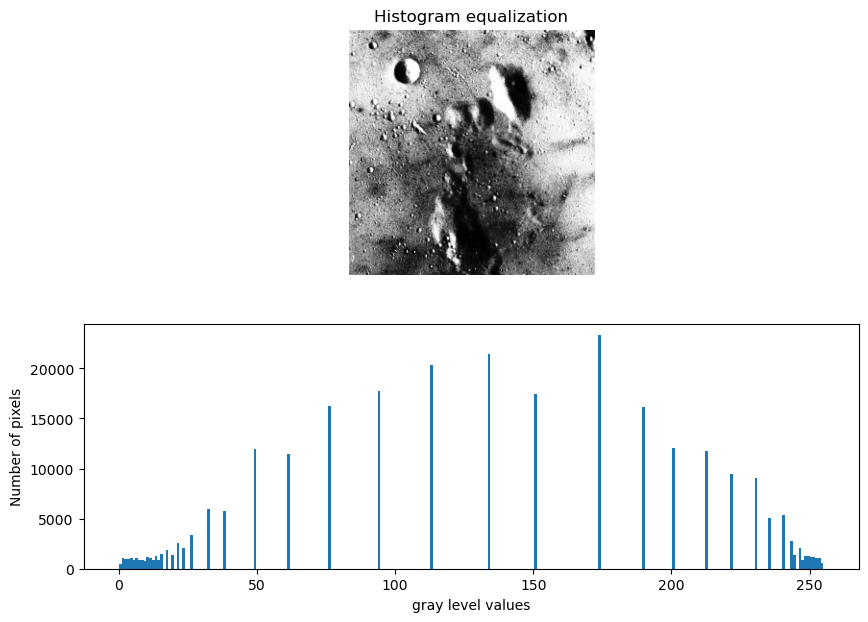

In [8]:
img = data.moon()

# Histogram equalization (returns a float image in [0, 1])
img_eq = exposure.equalize_hist(img)
img_eq_u8 = img_as_ubyte(img_eq)          # convert to 0–255 for a comparable histogram
print('equalize_hist output dtype:', img_eq.dtype, '| range:', img_eq.min(), '-', img_eq.max())

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_eq_u8, cmap='gray')
plt.axis('off')
plt.title('Histogram equalization')
fig.add_subplot(2, 1, 2)
plt.hist(img_eq_u8.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.savefig('outputs/B2_histogram_equalization.png', dpi=110, bbox_inches='tight')
plt.show()

To show the *flattening* effect clearly, the histograms are plotted together with their cumulative distribution functions (CDF):

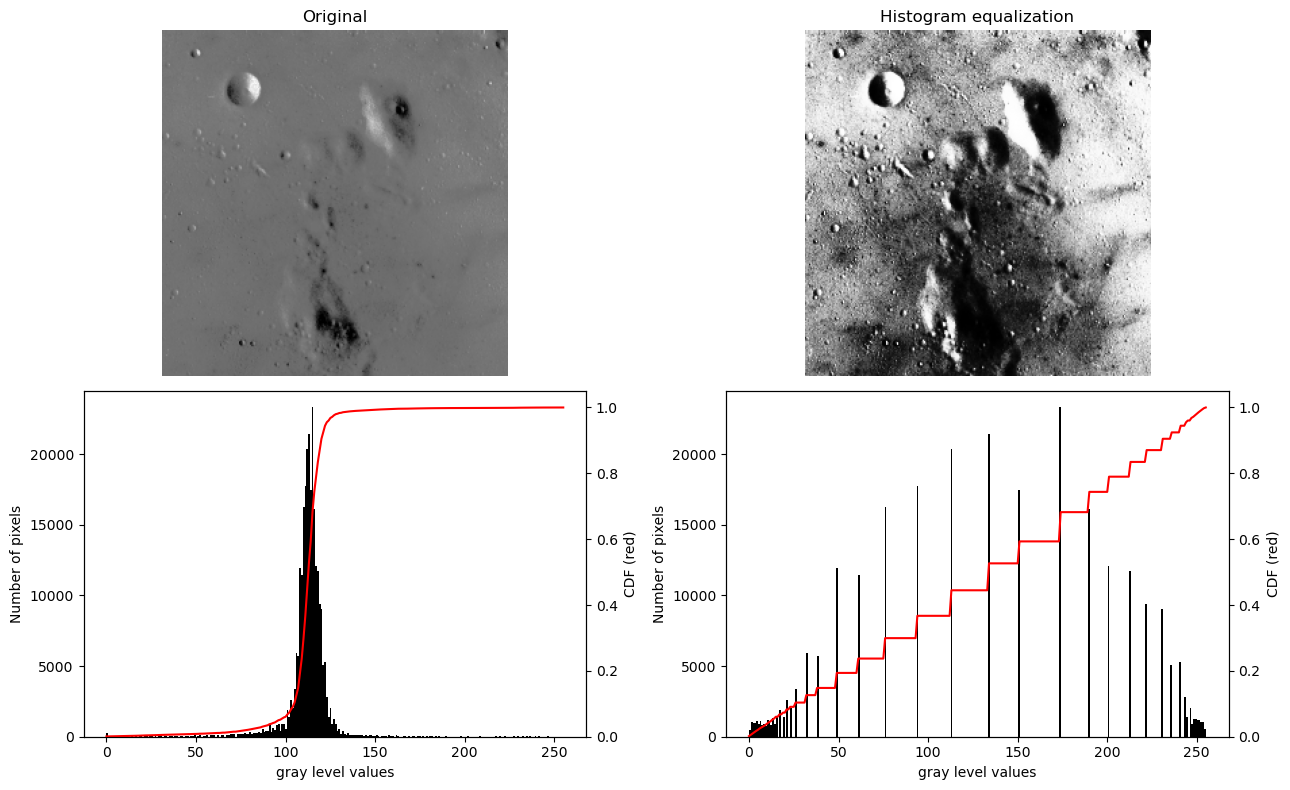

In [9]:
def plot_img_hist_cdf(image, ax_img, ax_hist, title):
    ax_img.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax_img.set_title(title)
    ax_img.axis('off')
    ax_hist.hist(image.ravel(), bins=256, range=(0, 255), color='black')
    ax_hist.set_xlabel('gray level values')
    ax_hist.set_ylabel('Number of pixels')
    cdf, bins = exposure.cumulative_distribution(image, 256)
    ax_cdf = ax_hist.twinx()
    ax_cdf.plot(bins, cdf, 'r')
    ax_cdf.set_ylim(0, 1.05)
    ax_cdf.set_ylabel('CDF (red)')

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
plot_img_hist_cdf(img, axes[0, 0], axes[1, 0], 'Original')
plot_img_hist_cdf(img_eq_u8, axes[0, 1], axes[1, 1], 'Histogram equalization')
plt.tight_layout()
plt.savefig('outputs/B2_equalization_cdf.png', dpi=110, bbox_inches='tight')
plt.show()

**Discussion:** `equalize_hist` maps each gray level through the image's normalized CDF. The narrow original histogram is spread over the full 0–255 range and becomes approximately flat (uniform), and the CDF turns into a nearly straight diagonal line. The equalized image shows strongly increased global contrast (crater edges and surface texture become very visible), although some noise in the darker background is also amplified.

## Assessment Task #3
Use the **rocket** image as the reference and the **Chelsea** image as the source (both from `skimage.data`) and implement **histogram matching**.

Histogram matching transforms the source image so that the cumulative histogram of each color channel matches that of the reference image. Since both images are RGB, matching is done channel by channel with `channel_axis=-1`.

Source (chelsea): (300, 451, 3) | Reference (rocket): (427, 640, 3)


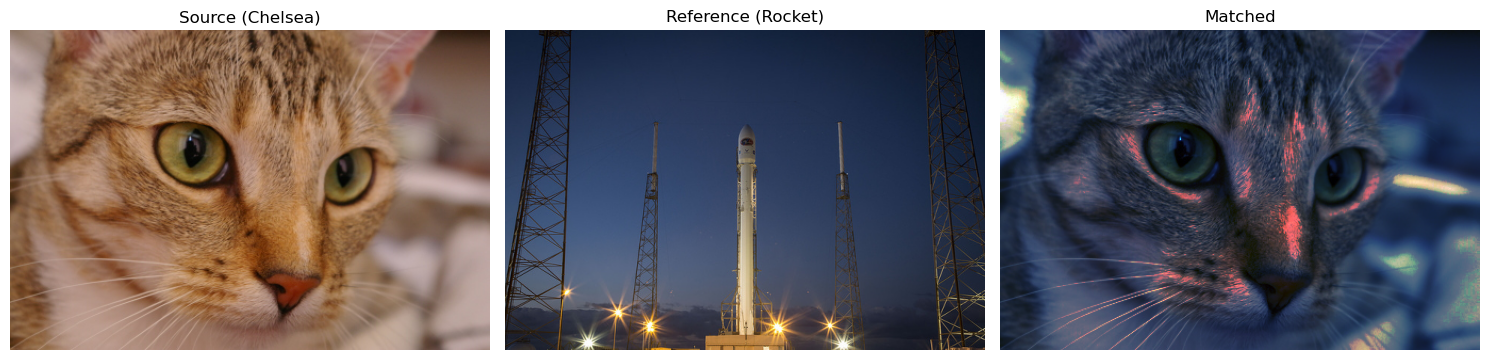

In [10]:
from skimage.exposure import match_histograms

reference = data.rocket()   # reference image
image = data.chelsea()      # source image
print('Source (chelsea):', image.shape, '| Reference (rocket):', reference.shape)

matched = match_histograms(image, reference, channel_axis=-1)
matched = np.clip(matched, 0, 255).astype(np.uint8)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.5))
for aa, im, t in zip((ax1, ax2, ax3), (image, reference, matched),
                     ('Source (Chelsea)', 'Reference (Rocket)', 'Matched')):
    aa.imshow(im)
    aa.set_title(t)
    aa.set_axis_off()
plt.tight_layout()
plt.savefig('outputs/B3_histogram_matching.png', dpi=110, bbox_inches='tight')
plt.show()

Per-channel histograms and cumulative histograms of the source, reference and matched images:

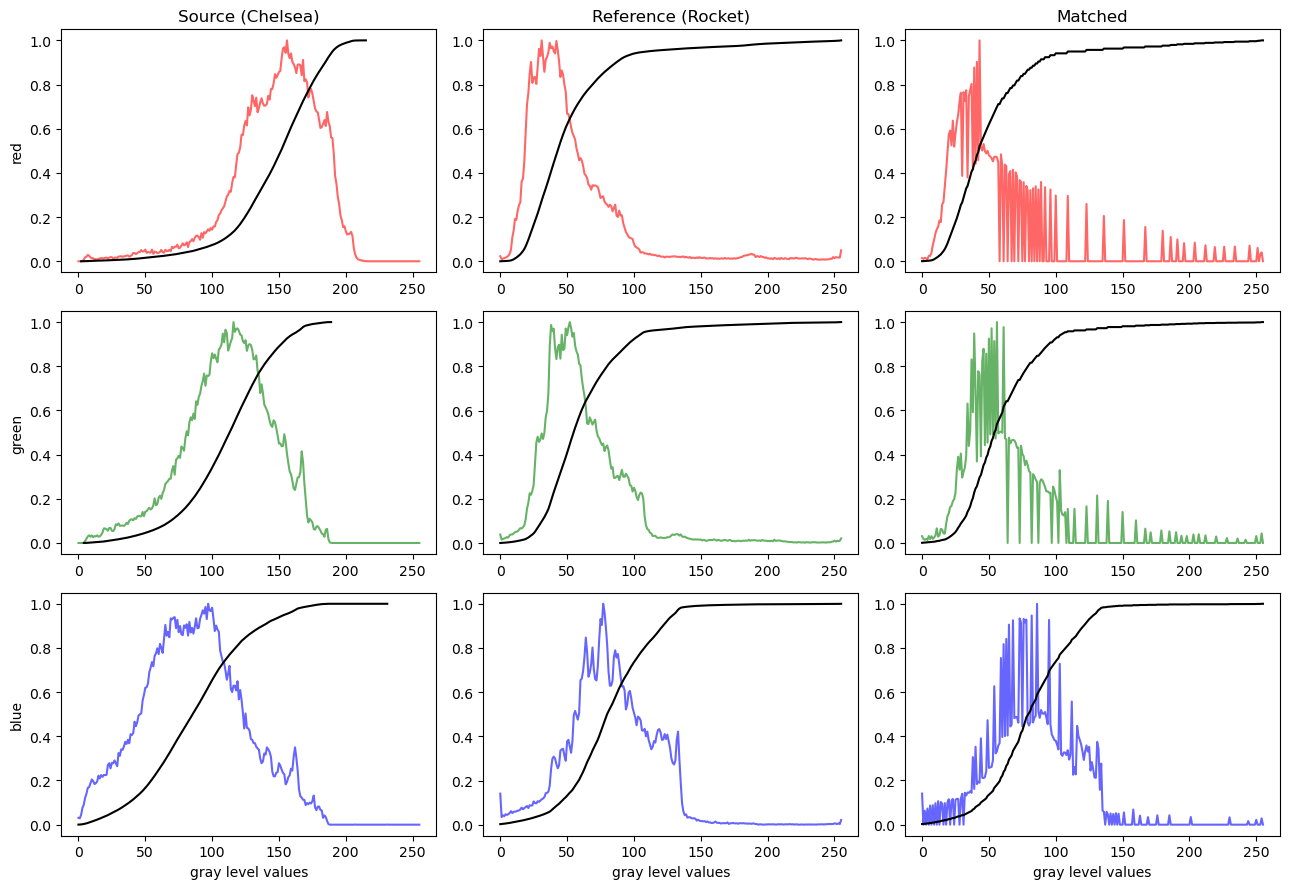

In [11]:
colors = ('red', 'green', 'blue')
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(13, 9))

for i, im in enumerate((image, reference, matched)):
    for c, c_color in enumerate(colors):
        img_hist, bins = exposure.histogram(im[..., c], source_range='dtype')
        axes[c, i].plot(bins, img_hist / img_hist.max(), color=c_color, alpha=0.6)
        img_cdf, bins = exposure.cumulative_distribution(im[..., c])
        axes[c, i].plot(bins, img_cdf, color='black')
        axes[c, 0].set_ylabel(c_color)

axes[0, 0].set_title('Source (Chelsea)')
axes[0, 1].set_title('Reference (Rocket)')
axes[0, 2].set_title('Matched')
for ax in axes[-1]:
    ax.set_xlabel('gray level values')
plt.tight_layout()
plt.savefig('outputs/B3_matching_histograms.png', dpi=110, bbox_inches='tight')
plt.show()

In [12]:
# Quantitative check: mean of each channel before/after matching
for c, name in enumerate(colors):
    print(f'{name:>5}: source mean = {image[..., c].mean():6.1f} | '
          f'reference mean = {reference[..., c].mean():6.1f} | '
          f'matched mean = {matched[..., c].mean():6.1f}')

  red: source mean =  147.7 | reference mean =   52.3 | matched mean =   52.1
green: source mean =  111.4 | reference mean =   61.3 | matched mean =   60.8
 blue: source mean =   86.8 | reference mean =   82.3 | matched mean =   81.7


**Discussion:** After matching, the cumulative histograms (black curves) of the matched image have the same shape as those of the rocket reference in every channel, and the channel means move to the reference values. Visually, the cat image keeps its content and structure but takes on the color and tonal distribution of the rocket scene (darker, cooler/blue-dominated tones — the red channel mean drops from 147.7 to 52.1). Some bright red spots appear where the cat's brightest red values are mapped to the rocket's few bright orange light sources. Histogram matching is therefore useful for normalizing images taken under different lighting or for transferring the tonal "look" of one image to another.

# Conclusion
In this lab we applied fixed-threshold binarization, contrast stretching with percentile-based limits (2–98 and 3–80), histogram equalization and histogram matching. Thresholding simplifies an image into foreground/background; contrast stretching linearly expands a chosen intensity range (a lower upper-percentile causes clipping/saturation); equalization flattens the histogram to maximize global contrast; and matching reshapes an image's histogram to follow a reference image.